# Boosted Decision Tree Skeleton


In this cell, split the dataset into _train_ and _test_ samples, using sci-kit learn `train_test_split()`.


In [37]:
import sys
sys.path.append("/users/xn22103/atmospherics-tools/fast-osc-feedback/")

import polars as pl
import uproot
import numpy as np
import awkward as ak
import matplotlib.pyplot as plt

#data loading and preprocessing

caf_tree = uproot.open("/storage/1/st15719/caf_new_sum.2.6M_weighted.root")["cafTree"]

#reco variables
# Enu_e_had= "rec/common/common.ixn.pandora/common.ixn.pandora.Enu.e_had"
# Enu_e_calo = "rec/common/common.ixn.pandora/common.ixn.pandora.Enu.e_calo"
# Enu_mu_had= "rec/common/common.ixn.pandora/common.ixn.pandora.Enu.mu_had"
# Enu_mu_range= "rec/common/common.ixn.pandora/common.ixn.pandora.Enu.mu_range"

#true variables
ineasticity = "rec/mc/mc.nu/mc.nu.inelasticity"
PDG = "rec/mc/mc.nu/mc.nu.pdg"

# caf_data = caf_tree.arrays([Enu_e_had, Enu_e_calo, Enu_mu_had, Enu_mu_range, PDG])
caf_data = caf_tree.arrays([ineasticity, PDG])

caf_df = pl.from_pandas(ak.to_dataframe(caf_data, how = "outer"))
# caf_df.columns = ["Enu_e_had","Enu_e_calo","Enu_mu_had","Enu_mu_range","PDG"]
caf_df.columns = ["inelasticity","PDG"]

print(len(caf_df))

event_daughters = uproot.open("event_daughters_info.root")["event_daughters_tree"]
event_daughters_df = pl.from_pandas(event_daughters.arrays(library="pd"))

print(len(event_daughters_df))

data = pl.concat([caf_df, event_daughters_df], how="horizontal")

print(len(data))

data = data.with_row_index("event_index")

#dont need reco check for truth info for truth test of bdt
# data = data.filter(pl.col("reco_ok") == True)

print(len(data))


data = data.with_columns(
# 	(1 - (pl.col("Enu_e_had") / pl.col("Enu_e_calo"))).alias("inelasticity_e"),
# 	(1 - (pl.col("Enu_mu_had") / pl.col("Enu_mu_range"))).alias("inelasticity_mu"),
	(pl.col("PDG") < 0).cast(pl.Int64).alias("label"))



data = data.to_pandas()
data = data.dropna()


2884703
2884703
2884703
2884703


In [38]:
caf_tree = uproot.open("/storage/1/st15719/caf_new_sum.2.6M_weighted.root")["cafTree"]
# list all branches containing 'nu'
for b in caf_tree.keys():
    if 'nu' in b.lower():
        print(b)

rec/mc/mc.nu
rec/mc/mc.nu/mc.nu.id
rec/mc/mc.nu/mc.nu.genieIdx
rec/mc/mc.nu/mc.nu.pdg
rec/mc/mc.nu/mc.nu.pdgorig
rec/mc/mc.nu/mc.nu.iscc
rec/mc/mc.nu/mc.nu.mode
rec/mc/mc.nu/mc.nu.targetPDG
rec/mc/mc.nu/mc.nu.hitnuc
rec/mc/mc.nu/mc.nu.removalE
rec/mc/mc.nu/mc.nu.E
rec/mc/mc.nu/mc.nu.vtx.x
rec/mc/mc.nu/mc.nu.vtx.y
rec/mc/mc.nu/mc.nu.vtx.z
rec/mc/mc.nu/mc.nu.momentum.x
rec/mc/mc.nu/mc.nu.momentum.y
rec/mc/mc.nu/mc.nu.momentum.z
rec/mc/mc.nu/mc.nu.isvtxcont
rec/mc/mc.nu/mc.nu.time
rec/mc/mc.nu/mc.nu.bjorkenX
rec/mc/mc.nu/mc.nu.inelasticity
rec/mc/mc.nu/mc.nu.Q2
rec/mc/mc.nu/mc.nu.q0
rec/mc/mc.nu/mc.nu.modq
rec/mc/mc.nu/mc.nu.W
rec/mc/mc.nu/mc.nu.t
rec/mc/mc.nu/mc.nu.ischarm
rec/mc/mc.nu/mc.nu.isseaquark
rec/mc/mc.nu/mc.nu.resnum
rec/mc/mc.nu/mc.nu.xsec
rec/mc/mc.nu/mc.nu.genweight
rec/mc/mc.nu/mc.nu.baseline
rec/mc/mc.nu/mc.nu.prod_vtx.x
rec/mc/mc.nu/mc.nu.prod_vtx.y
rec/mc/mc.nu/mc.nu.prod_vtx.z
rec/mc/mc.nu/mc.nu.parent_dcy_mom.x
rec/mc/mc.nu/mc.nu.parent_dcy_mom.y
rec/mc/mc.nu/mc.nu.pa

In [39]:
data.columns

Index(['event_index', 'inelasticity', 'PDG', 'reco_ok', 'n_reco_pfps',
       'n_reco_tracks', 'n_reco_showers', 'single_hits_energy',
       'n_reco_muons_pions', 'n_reco_protons', 'n_true_nu',
       'n_primary_daughters', 'n_primary_electrons', 'n_primary_muons',
       'n_primary_protons', 'n_primary_pions', 'n_primary_photons',
       'n_primary_pi0s', 'n_primary_tracks', 'n_primary_showers', 'label'],
      dtype='object')

In [40]:
# code to set only the inelasticity of the correct neutrino type to non zero for each event

# import numpy as np

# data["inelasticity"] = np.select([data["PDG"].abs() == 14,data["PDG"].abs() == 12,],[data["inelasticity_mu"],data["inelasticity_e"],],default=np.nan)

# data = data.drop(columns=["inelasticity_e", "inelasticity_mu"])

# data= data[data["PDG"].abs() != 16]


data

,event_index,inelasticity,PDG,reco_ok,n_reco_pfps,n_reco_tracks,n_reco_showers,single_hits_energy,n_reco_muons_pions,n_reco_protons,...,n_primary_daughters,n_primary_electrons,n_primary_muons,n_primary_protons,n_primary_pions,n_primary_photons,n_primary_pi0s,n_primary_tracks,n_primary_showers,label
0,0,0.097032,-12,True,10,5,4,11.487990,4,1,...,5,1,0,0,1,0,1,1,3,1
1,1,0.543771,-12,True,2,1,0,0.110940,1,0,...,4,1,0,1,0,1,0,1,1,1
2,2,0.464560,-14,True,4,3,0,0.064570,2,1,...,6,0,1,0,2,0,0,3,0,1
3,3,0.140807,16,False,-1,-1,-1,-1.000000,-1,-1,...,8,0,0,1,0,0,0,1,0,0
4,4,0.208293,14,True,3,2,0,0.002420,1,1,...,3,0,1,1,0,1,0,2,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2884698,2884698,0.597658,14,True,2,1,0,0.000000,1,0,...,3,0,0,1,0,1,0,1,0,0
2884699,2884699,0.171440,14,True,2,1,0,0.005397,1,0,...,3,0,1,1,0,0,0,2,0,0
2884700,2884700,0.307673,14,True,3,1,1,0.012165,1,0,...,6,0,1,2,0,1,0,3,0,0
2884701,2884701,0.220781,12,True,3,1,1,0.102556,0,1,...,4,0,0,1,0,0,1,1,2,0


In [41]:
import pandas as pd

consistency = pd.crosstab(data['PDG'] < 0, data['label'])
consistency.index = ['PDG > 0 (Nu)', 'PDG < 0 (Anti-Nu)']
consistency.columns = ['Label 0', 'Label 1']
print(consistency)

                   Label 0  Label 1
PDG > 0 (Nu)       2139536        0
PDG < 0 (Anti-Nu)        0   745167


In [42]:
electron_mask = data['PDG'].abs() == 12
muon_mask = data['PDG'].abs() == 14
tau_mask = data['PDG'].abs() == 16


electron_data = data[electron_mask]
muon_data = data[muon_mask] 
tau_data = data[tau_mask]
data_pfp_1 = data[data["n_reco_pfps"] > 1]
# data_E_10gev = data_pfp_1[data_pfp_1["E"] > 10]

In [43]:
data_type = data_pfp_1


feature_columns = ['inelasticity', 'n_reco_pfps', 'n_reco_tracks', 'n_reco_showers', 'single_hits_energy', 'n_reco_muons_pions', 'n_reco_protons']
data = data_type.dropna()

# for col in [
# 	"single_hits_energy",
# 	"n_reco_pfps",
# 	"n_reco_tracks",
# 	"n_reco_showers",
# 	"n_reco_protons",
# ]:
# 	data[col] = np.log1p(data[col])


X_data = data_type[feature_columns].values


y_data = data_type['label'].values

data_type[feature_columns]

,inelasticity,n_reco_pfps,n_reco_tracks,n_reco_showers,single_hits_energy,n_reco_muons_pions,n_reco_protons
0,0.097032,10,5,4,11.487990,4,1
1,0.543771,2,1,0,0.110940,1,0
2,0.464560,4,3,0,0.064570,2,1
4,0.208293,3,2,0,0.002420,1,1
5,0.357354,2,1,0,0.003319,1,0
...,...,...,...,...,...,...,...
2884698,0.597658,2,1,0,0.000000,1,0
2884699,0.171440,2,1,0,0.005397,1,0
2884700,0.307673,3,1,1,0.012165,1,0
2884701,0.220781,3,1,1,0.102556,0,1


In [44]:
print(np.unique(y_data, return_counts=True))


(array([0, 1]), array([1981454,  669573]))


In [45]:
from sklearn.model_selection import train_test_split

# split the data into train and test datasets
X_train, X_test, y_train, y_test = train_test_split(
    X_data, y_data, test_size=0.33, random_state=42)

Train the BDT using the `GradientBoostingClassifier` from sci-kit learn.  Note that `HistGradientBoostingClassifier` is also available, and should be more computationally efficient on large samples (>10k).

In [46]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
clf = HistGradientBoostingClassifier(
	learning_rate=0.05,
	max_depth=None,
    max_leaf_nodes=31,
	min_samples_leaf=50,
	max_iter=2000,
	class_weight="balanced",
	early_stopping=True,
	# validation_fraction=0.2,
	# n_iter_no_change=30,
	random_state=0,
).fit(X_train, y_train)

Now generate predictions (i.e. log-odds probabilities for each event) for both the test and train samples.

In [47]:
# create the result for train datasest
scores_train = clf.decision_function(X_train)

# create the results for test dataset
scores_test = clf.decision_function(X_test)

In [48]:
n_index = 0 
an_index = 1

print(np.unique(y_test, return_counts=True))



(array([0, 1]), array([653567, 221272]))


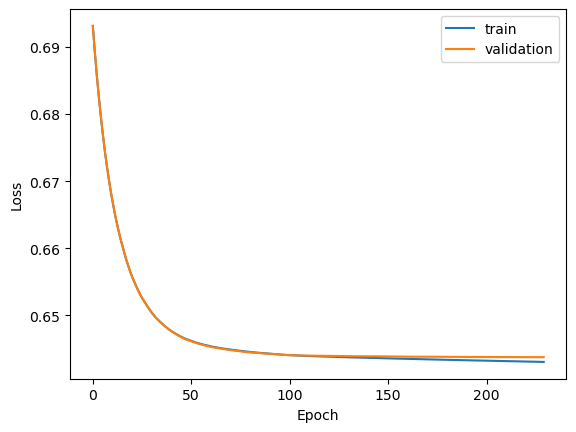

In [49]:
train_loss = [-s for s in clf.train_score_]
val_loss   = [-s for s in clf.validation_score_]

plt.plot(train_loss, label="train")
plt.plot(val_loss, label="validation")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


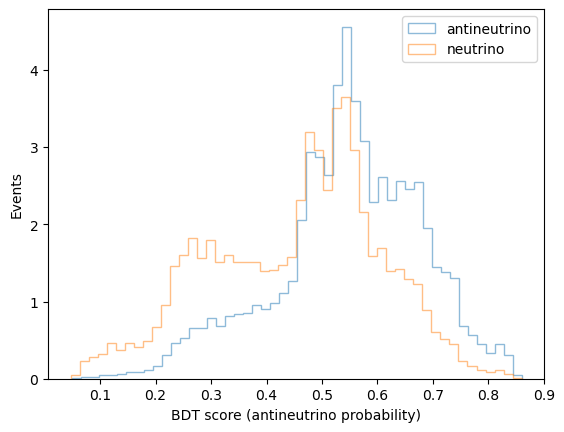

[0.43450438 0.501437   0.54098395 ... 0.51824175 0.43799869 0.5515528 ]


In [50]:


score = clf.predict_proba(X_test)[:,1]


plt.hist(score[y_test==1], bins=50, alpha=0.5, label="antineutrino", density = True,  histtype="step")
plt.hist(score[y_test==0], bins=50, alpha=0.5, label="neutrino", density = True, histtype="step")

plt.xlabel("BDT score (antineutrino probability)")
plt.ylabel("Events")
plt.legend()
plt.show()

print(score)

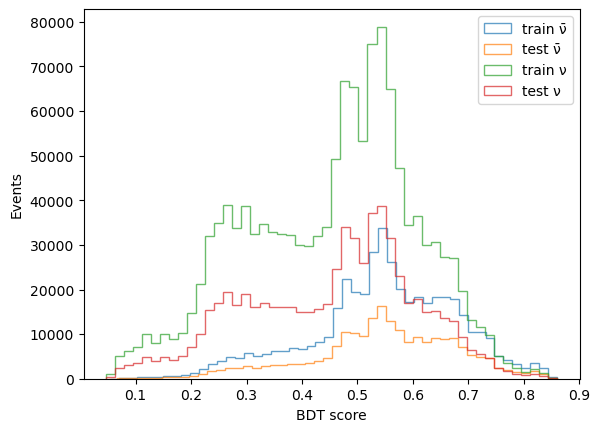

In [51]:
score_train = clf.predict_proba(X_train)[:,1]
score_test  = clf.predict_proba(X_test)[:,1]

plt.hist(score_train[y_train==1], bins=50, alpha=0.7, label="train ν̄",histtype = 'step')
plt.hist(score_test[y_test==1],  bins=50, alpha=0.7, label="test ν̄", histtype = 'step')

plt.hist(score_train[y_train==0], bins=50, alpha=0.7, label="train ν", histtype = 'step')
plt.hist(score_test[y_test==0],  bins=50, alpha=0.7, label="test ν", histtype = 'step')

plt.xlabel("BDT score")
plt.ylabel("Events")
plt.legend()
plt.show()



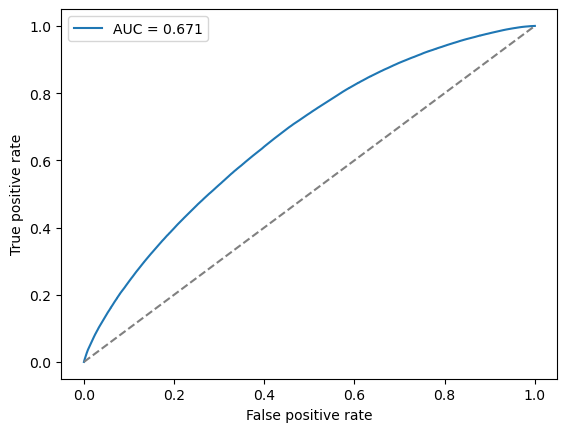

In [52]:
from sklearn.metrics import roc_curve, auc

probs = clf.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, probs)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1], linestyle="--", color="gray")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.legend()
plt.show()


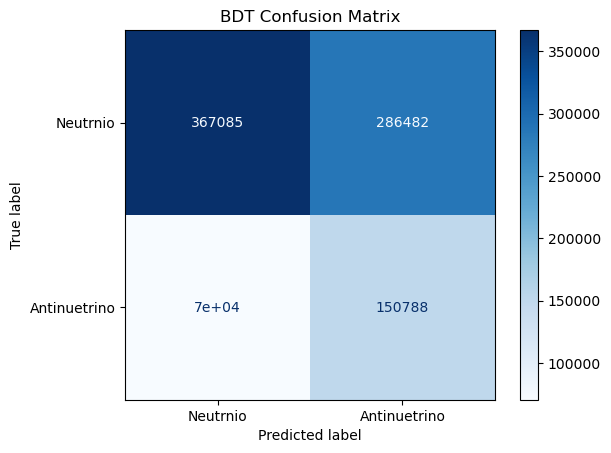

In [53]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = clf.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Neutrnio', 'Antinuetrino'])
disp.plot(cmap=plt.cm.Blues)
plt.title("BDT Confusion Matrix")
plt.show()

In [54]:
from sklearn.inspection import permutation_importance
r = permutation_importance(clf, X_data, y_data, n_repeats=5)


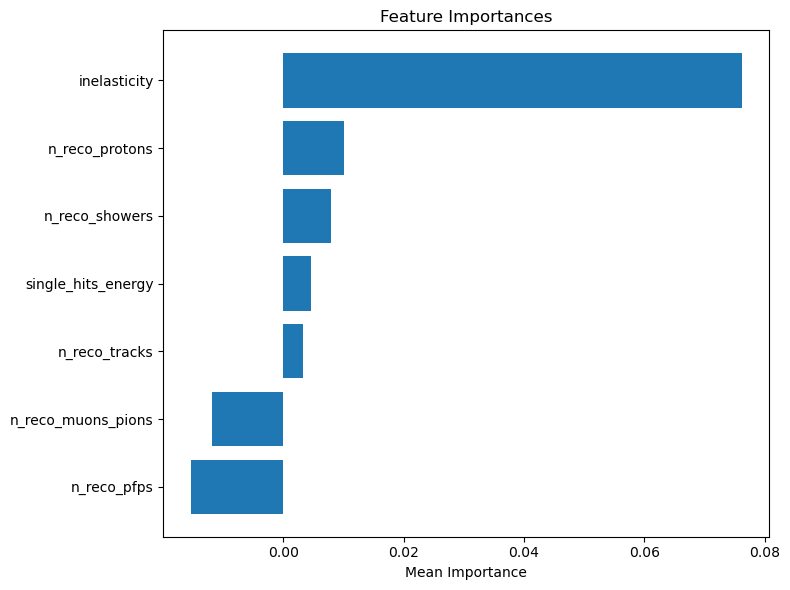

In [63]:
means = r["importances_mean"]
sorted_idx = np.argsort(means)

plt.figure(figsize=(8, 6))
plt.barh(
    [feature_columns[i] for i in sorted_idx],
    means[sorted_idx]
)
plt.xlabel("Mean Importance")
plt.title("Feature Importances")
plt.tight_layout()
plt.show()

In [56]:
from sklearn.metrics import log_loss

x = log_loss(y_true=y_test, y_pred=probs)
print(x)

0.6452229836279695


In [57]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred, target_names=['Neutrino', 'Antineutrino']))

              precision    recall  f1-score   support

    Neutrino       0.84      0.56      0.67    653567
Antineutrino       0.34      0.68      0.46    221272

    accuracy                           0.59    874839
   macro avg       0.59      0.62      0.57    874839
weighted avg       0.71      0.59      0.62    874839



874839
2651027
874838.91


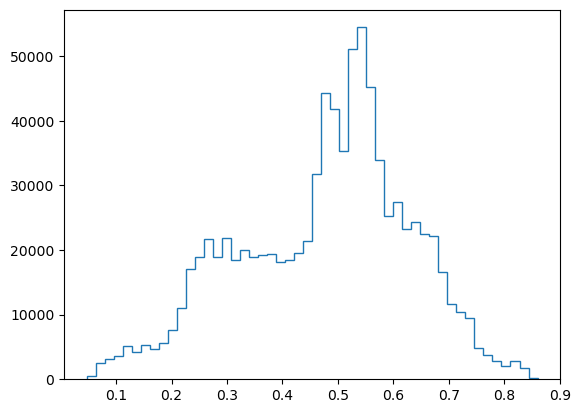

In [58]:
plt.hist(score, histtype="step", bins=50, label="test" )
print(len(score))
print(len(y_data))
print(0.33*len(y_data))

In [59]:
hard_predictions = clf.predict(X_data)
probs = clf.predict_proba(X_data)
decision_scores = clf.decision_function(X_data)


results_df = pd.DataFrame({
    'true_label': y_data,
    'predicted_label': hard_predictions,
    'prob_neutrino': probs[:, 0],
    'prob_antineutrino': probs[:, 1],
    'decision_score': decision_scores
})



print(results_df.head())

   true_label  predicted_label  prob_neutrino  prob_antineutrino  \
0           1                1       0.305147           0.694853   
1           1                1       0.485410           0.514590   
2           1                0       0.638547           0.361453   
3           0                0       0.898862           0.101138   
4           0                0       0.528510           0.471490   

   decision_score  
0        0.822904  
1        0.058378  
2       -0.569063  
3       -2.184639  
4       -0.114165  


In [60]:
score_column = results_df['prob_antineutrino']

In [61]:
all_probs = clf.predict_proba(X_data)[:, 1]

final_output = pd.DataFrame({
    'event_index': data['event_index'],
    'bdt_score': all_probs
})

final_output.to_csv("cheated_bdt_scores_with_index.csv", index=False)

In [62]:
final_output

,event_index,bdt_score
0,0,0.694853
1,1,0.514590
2,2,0.361453
4,4,0.101138
5,5,0.471490
...,...,...
2884698,2884698,0.487055
2884699,2884699,0.522010
2884700,2884700,0.267837
2884701,2884701,0.441889
